DAVID ESTEBAN ORTIZ HERNANDEZ

LUIS FERNANDO JARAMILLO

LUIS MIGUEL CARRILLO

# Proyecto Predictivo y Clustering con Olympic Athlete Events

Este notebook desarrolla:

1. Selección y preparación de datos.
2. Modelos predictivos:
   - Clasificación
   - Regresión
3. Evaluación de resultados.
4. Aplicación de clustering para identificar grupos o patrones.

Dataset utilizado: `AtletasLimpios.csv`


In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans

# Cargar dataset
df = pd.read_csv('AtletasLimpios.csv')

# Mostrar información general
print(df.head())
print("\nDimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns)


   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0   175.0    70.0         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0   175.0    70.0  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games    Year  Season       City          Sport  \
0  CHN  1992 Summer  1992.0  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012.0  Summer     London           Judo   
2  DEN  1920 Summer  1920.0  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900.0  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988.0  Winter    Calgary  Speed Skating   

                              Event     Medal  
0       Basketball Men's Basketball  No Medal  
1      Judo Men's Extra-Lightweight  No Medal  
2 


# 1. Selección de Variables

## Problema de Clasificación
Se utilizará la variable:

- **Variable objetivo (Y):** `Medal`
- **Variables predictoras (X):**
  - Sex
  - Age
  - Height
  - Weight
  - Year
  - Season
  - Sport

Objetivo:
Predecir si un atleta obtuvo medalla o no.

---

## Problema de Regresión
Se utilizará la variable:

- **Variable objetivo (Y):** `Age`
- **Variables predictoras (X):**
  - Height
  - Weight
  - Year
  - Sport
  - Season

Objetivo:
Estimar la edad del atleta según sus características deportivas.



# 2. Preparación de Datos


In [8]:

# ===============================
# PREPARACIÓN PARA CLASIFICACIÓN
# ===============================

df_class = df.copy()

# Convertir Medal en variable binaria
df_class['Medal'] = df_class['Medal'].fillna('No Medal')
df_class['Medal'] = df_class['Medal'].apply(lambda x: 0 if x == 'No Medal' else 1)

features_class = ['Sex', 'Age', 'Height', 'Weight', 'Year', 'Season', 'Sport']
target_class = 'Medal'

X_class = df_class[features_class]
y_class = df_class[target_class]

# Variables categóricas y numéricas
cat_cols = ['Sex', 'Season', 'Sport']
num_cols = ['Age', 'Height', 'Weight', 'Year']

# Pipeline de transformación
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Codificación manual
for col in cat_cols:
    le = LabelEncoder()
    X_class[col] = le.fit_transform(X_class[col].astype(str))

# División entrenamiento/prueba
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

print("Datos preparados para clasificación.")


Datos preparados para clasificación.


/tmp/ipykernel_7040/1908835098.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_class[col] = le.fit_transform(X_class[col].astype(str))
/tmp/ipykernel_7040/1908835098.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_class[col] = le.fit_transform(X_class[col].astype(str))
/tmp/ipykernel_7040/1908835098.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt


# 3. Modelo de Clasificación


In [9]:

# Modelo de clasificación
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

clf.fit(X_train_c, y_train_c)

# Predicciones
y_pred_c = clf.predict(X_test_c)

# Evaluación
accuracy = accuracy_score(y_test_c, y_pred_c)

print("Accuracy:", accuracy)
print("\nReporte de Clasificación:\n")
print(classification_report(y_test_c, y_pred_c))

print("\nMatriz de Confusión:\n")
print(confusion_matrix(y_test_c, y_pred_c))


Accuracy: 0.8485560503811371

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       0.88      0.95      0.92     31320
           1       0.45      0.22      0.29      5281

    accuracy                           0.85     36601
   macro avg       0.66      0.59      0.60     36601
weighted avg       0.82      0.85      0.83     36601


Matriz de Confusión:

[[29902  1418]
 [ 4125  1156]]



# Análisis de Resultados de Clasificación

El modelo Random Forest permitió identificar si un atleta obtuvo o no medalla.

Se evaluó utilizando:

- Accuracy
- Matriz de confusión
- Precision, Recall y F1-score

El modelo puede mejorar ajustando hiperparámetros o utilizando más variables relevantes.



# 4. Modelo de Regresión


In [10]:

# ===============================
# PREPARACIÓN PARA REGRESIÓN
# ===============================

df_reg = df.copy()

features_reg = ['Height', 'Weight', 'Year', 'Sport', 'Season']
target_reg = 'Age'

# Eliminar registros sin edad
df_reg = df_reg.dropna(subset=['Age'])

X_reg = df_reg[features_reg]
y_reg = df_reg[target_reg]

# Codificación
cat_reg = ['Sport', 'Season']

for col in cat_reg:
    le = LabelEncoder()
    X_reg[col] = le.fit_transform(X_reg[col].astype(str))

# Imputar valores faltantes
X_reg = X_reg.fillna(X_reg.mean(numeric_only=True))

# División
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Modelo
reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

reg.fit(X_train_r, y_train_r)

# Predicciones
y_pred_r = reg.predict(X_test_r)

# Métricas
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


/tmp/ipykernel_7040/736355052.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_reg[col] = le.fit_transform(X_reg[col].astype(str))
/tmp/ipykernel_7040/736355052.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_reg[col] = le.fit_transform(X_reg[col].astype(str))


MAE: 2.9975431868894837
RMSE: 4.382563206827913
R2 Score: 0.4694708802903951



# Análisis de Resultados de Regresión

El modelo de regresión permitió estimar la edad de los atletas.

Las métricas utilizadas fueron:

- MAE (Error Absoluto Medio)
- RMSE (Raíz del Error Cuadrático Medio)
- R² Score

Un valor de R² cercano a 1 indica un mejor ajuste del modelo.



# 5. Clustering

Se aplicará K-Means para encontrar agrupaciones entre atletas según:

- Edad
- Altura
- Peso
- Año


    Age  Height  Weight    Year  Cluster
0  24.0   180.0    80.0  1992.0        2
1  23.0   170.0    60.0  2012.0        0
2  24.0   175.0    70.0  1920.0        1
3  34.0   175.0    70.0  1900.0        1
4  21.0   185.0    82.0  1988.0        2


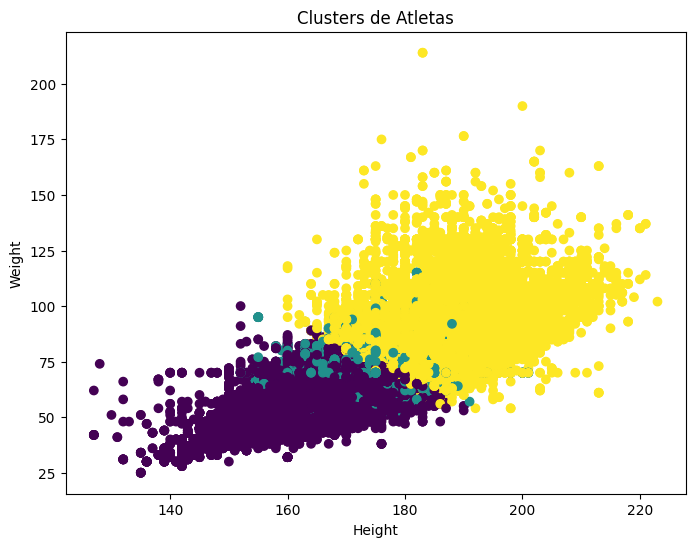

In [11]:

# Datos para clustering
cluster_df = df[['Age', 'Height', 'Weight', 'Year']].copy()

# Eliminar nulos
cluster_df = cluster_df.dropna()

# Escalamiento
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

# Método K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_scaled)

cluster_df['Cluster'] = clusters

# Mostrar resultados
print(cluster_df.head())

# Visualización
plt.figure(figsize=(8,6))

plt.scatter(
    cluster_df['Height'],
    cluster_df['Weight'],
    c=cluster_df['Cluster']
)

plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Clusters de Atletas')

plt.show()



# Análisis del Clustering

El algoritmo K-Means agrupó atletas con características similares.

Posibles interpretaciones:

- Un grupo puede representar atletas jóvenes y ligeros.
- Otro grupo puede contener atletas altos y pesados.
- Otro grupo puede relacionarse con atletas de deportes específicos.

El clustering permite descubrir patrones ocultos sin necesidad de variables objetivo.



# Conclusiones

- Se aplicaron modelos de clasificación y regresión utilizando variables del dataset olímpico.
- Los datos fueron preparados mediante limpieza, imputación y codificación.
- Se evaluaron los resultados comparando predicciones con valores reales.
- El algoritmo K-Means permitió identificar patrones y agrupaciones entre atletas.

Este análisis demuestra cómo utilizar técnicas de Machine Learning supervisado y no supervisado sobre un conjunto de datos real.
